In [1]:
# Setup
import json
from importlib import import_module
from pathlib import Path

import numpy as np

from src.utils import plot_correlation, plot_distribution, print, tex_to_str

In [2]:
# Parameters: entered
# Dataset
dataset_name = "real1"  # * (mock1, mock2, mock3, mock4, mock5, mock6, real1)

# Path
FIGURES_DIR = Path("figures")

In [3]:
# Parameters: derived
# Config
with open("1-dataset:config.json", "r") as f:
    dataset_config = json.load(f)

# Dataset
features = dataset_config[dataset_name]["features"]
n_samples = dataset_config[dataset_name]["n_samples"]
seed = dataset_config[dataset_name]["seed"]

# Figure
bins_kwargs = dataset_config[dataset_name]["bins"]
if dataset_name == "real1":
    bins = [np.linspace(**kwargs) for kwargs in bins_kwargs]
else:
    bins = [np.linspace(**bins_kwargs)] * len(features)

# Path
prefix = f"1-dataset:{dataset_name}-"
suffix = ""

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset_name}")
load_data = getattr(module, "load_data")

if dataset_name == "mock6":
    (x_train, y_train), (x_test, y_test), order = load_data(n_samples, seed)
    features = [features[i] for i in order]
else:
    (x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 6)
y_train.shape=(100000, 1)
x_test.shape=(100000, 6)
y_test.shape=(100000, 1)


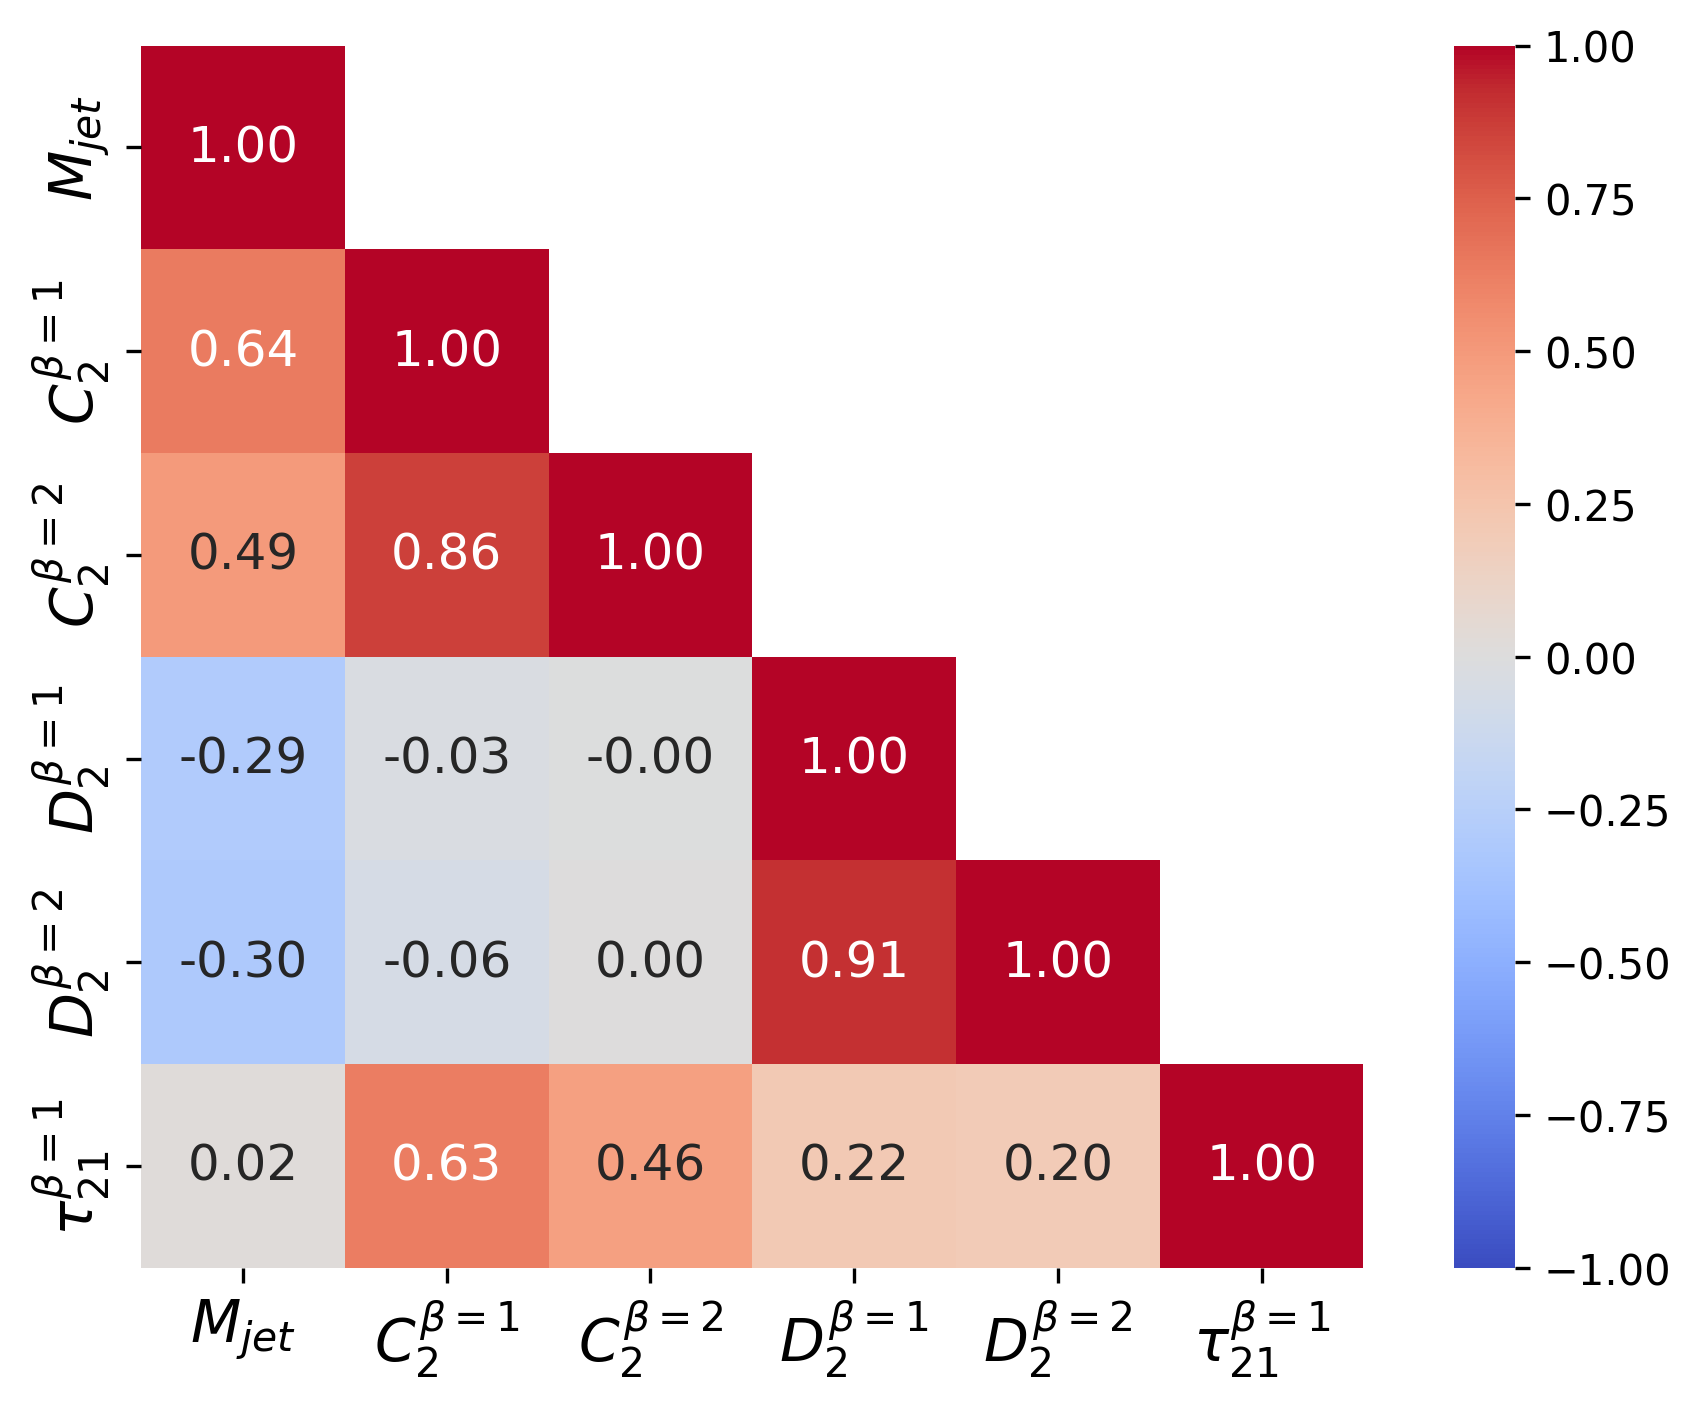

In [5]:
# Figure: correlation
plot_correlation(data=x_train, features=features)

plot_correlation(
    data=x_train,
    features=features,
    to_file=FIGURES_DIR / f"{prefix}correlation{suffix}.pdf",
)

plot_correlation(
    data=x_train,
    features=features,
    to_file=FIGURES_DIR / f"{prefix}correlation{suffix}.png",
)

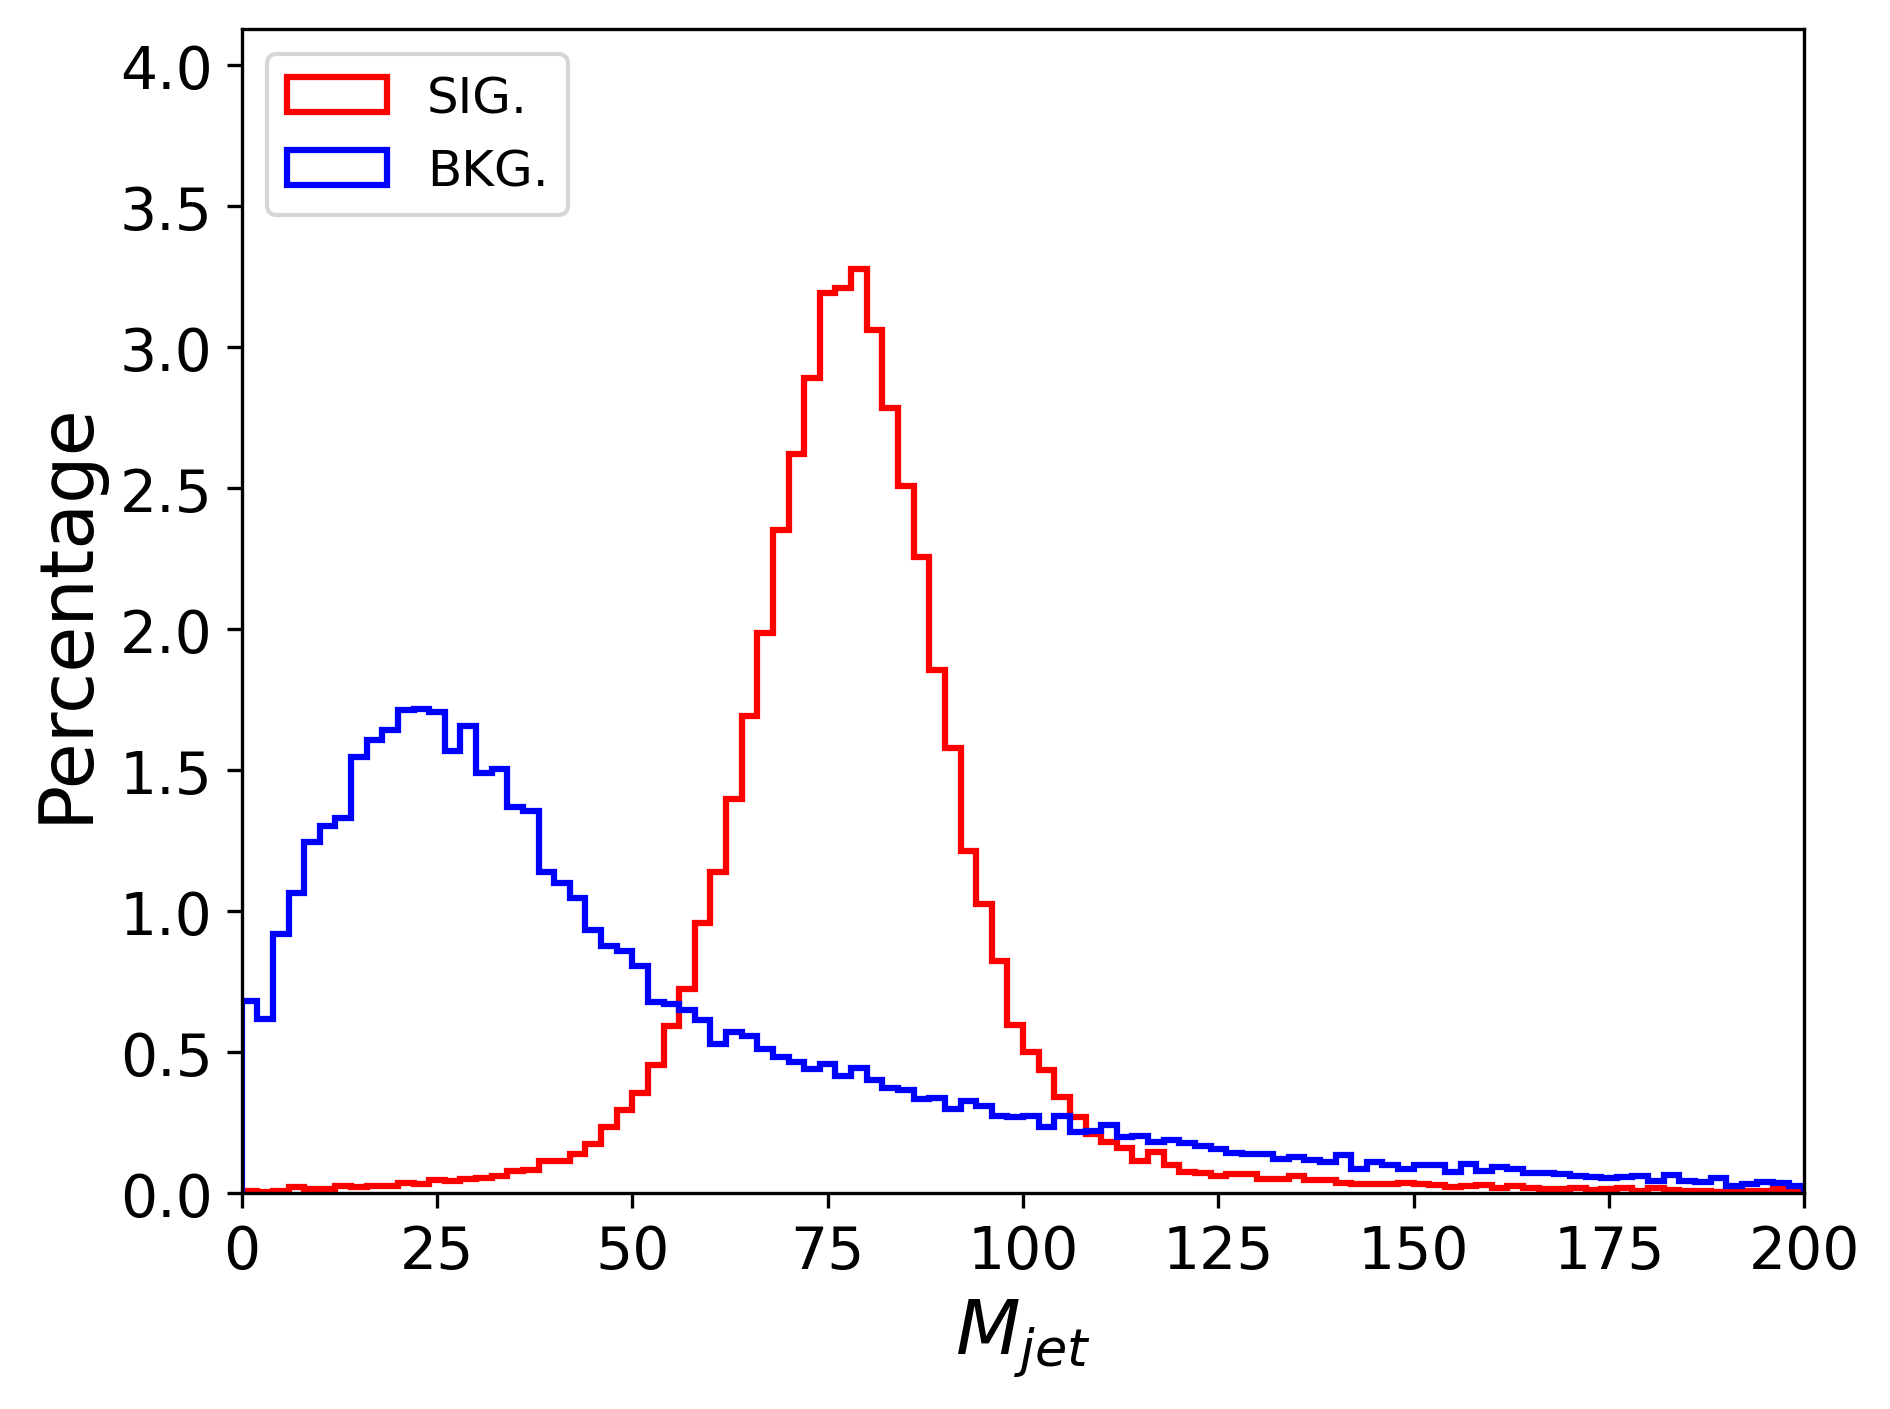

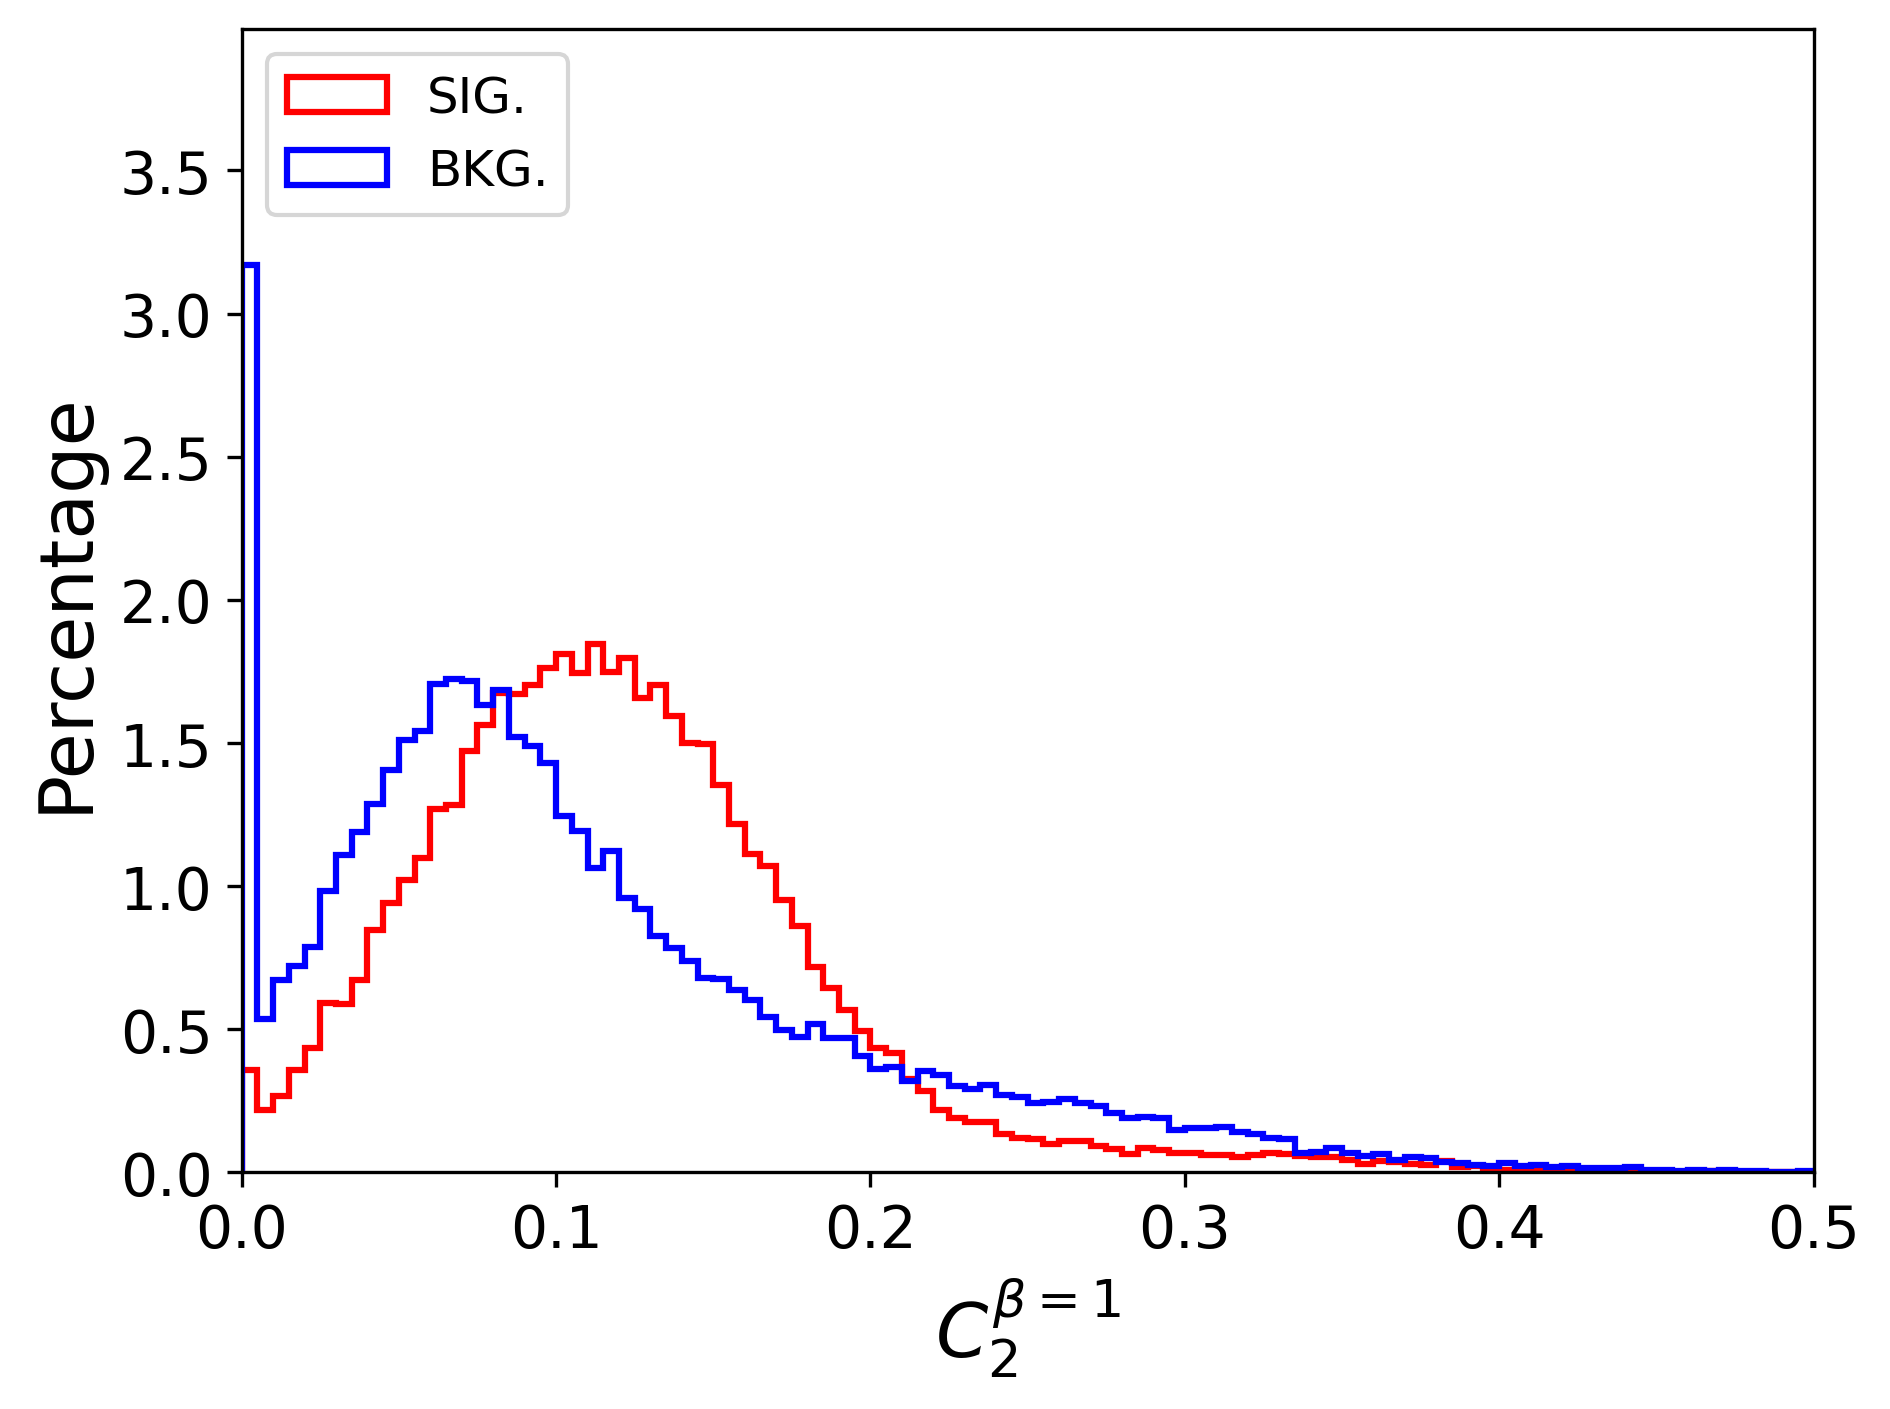

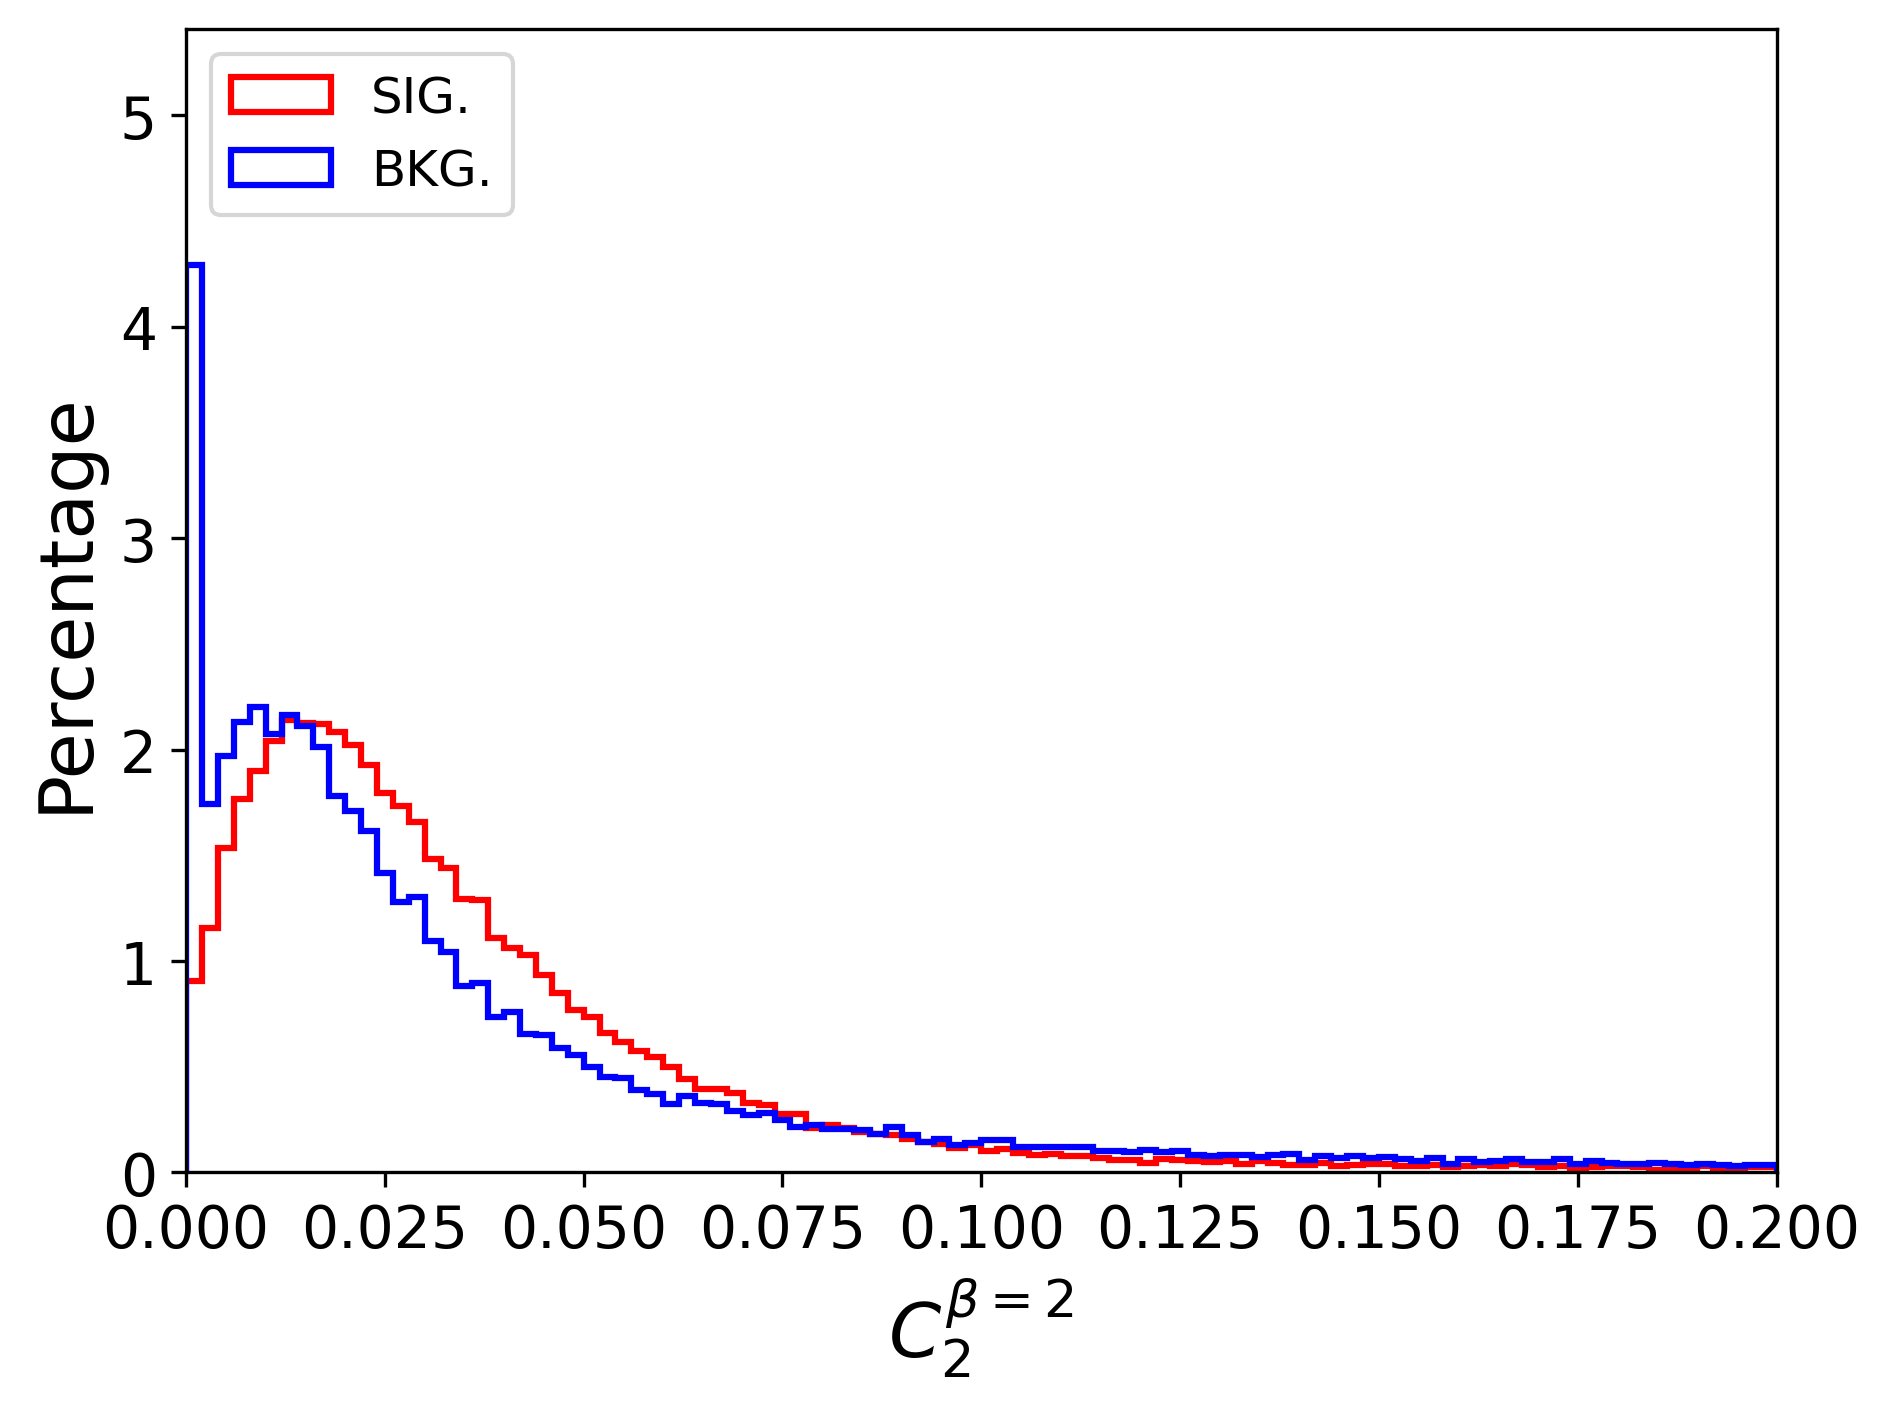

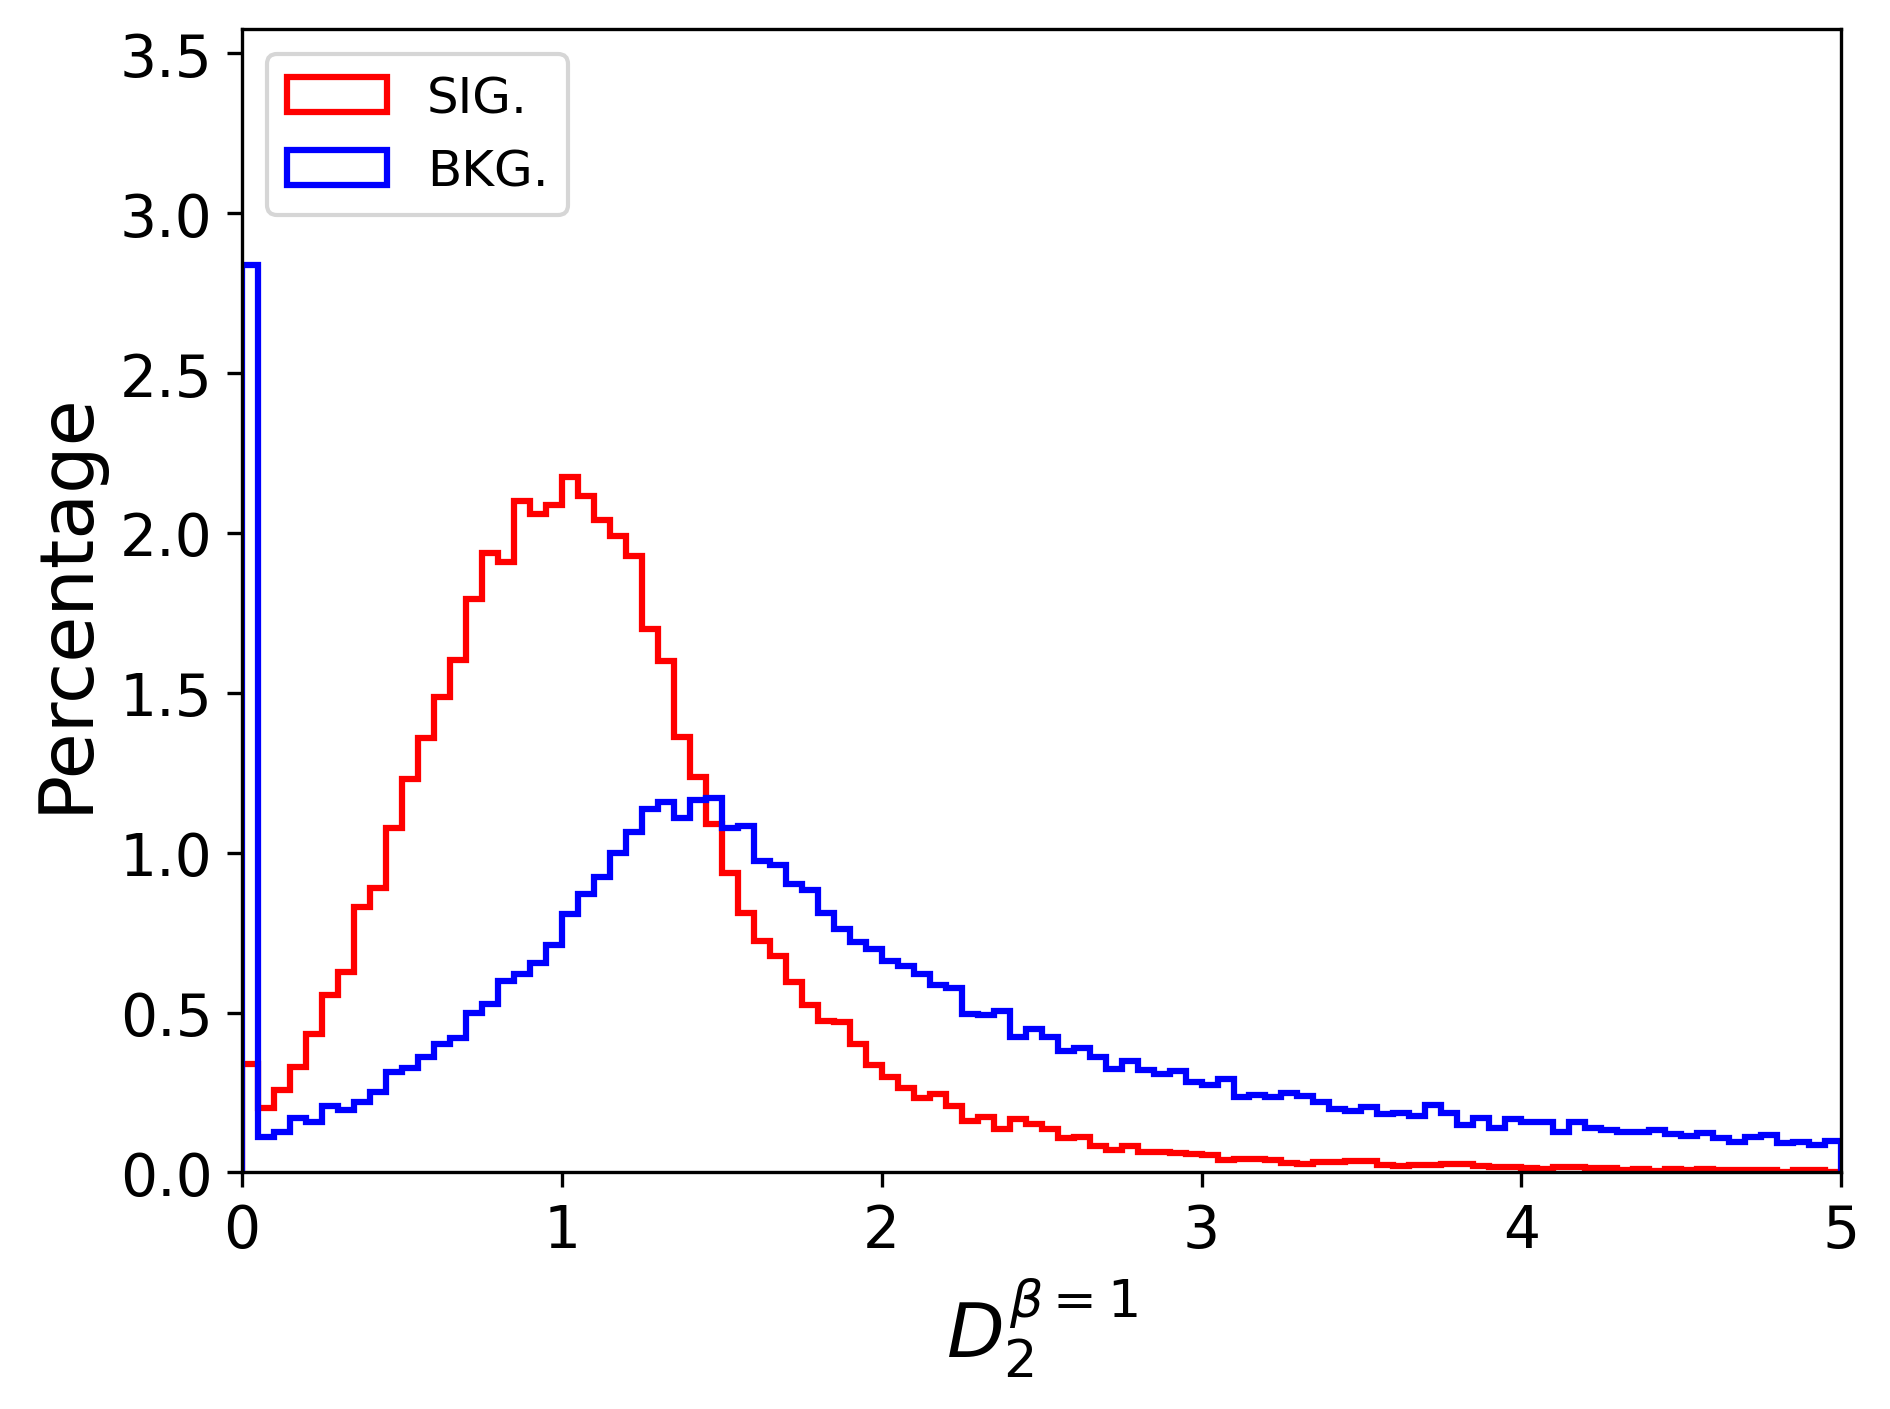

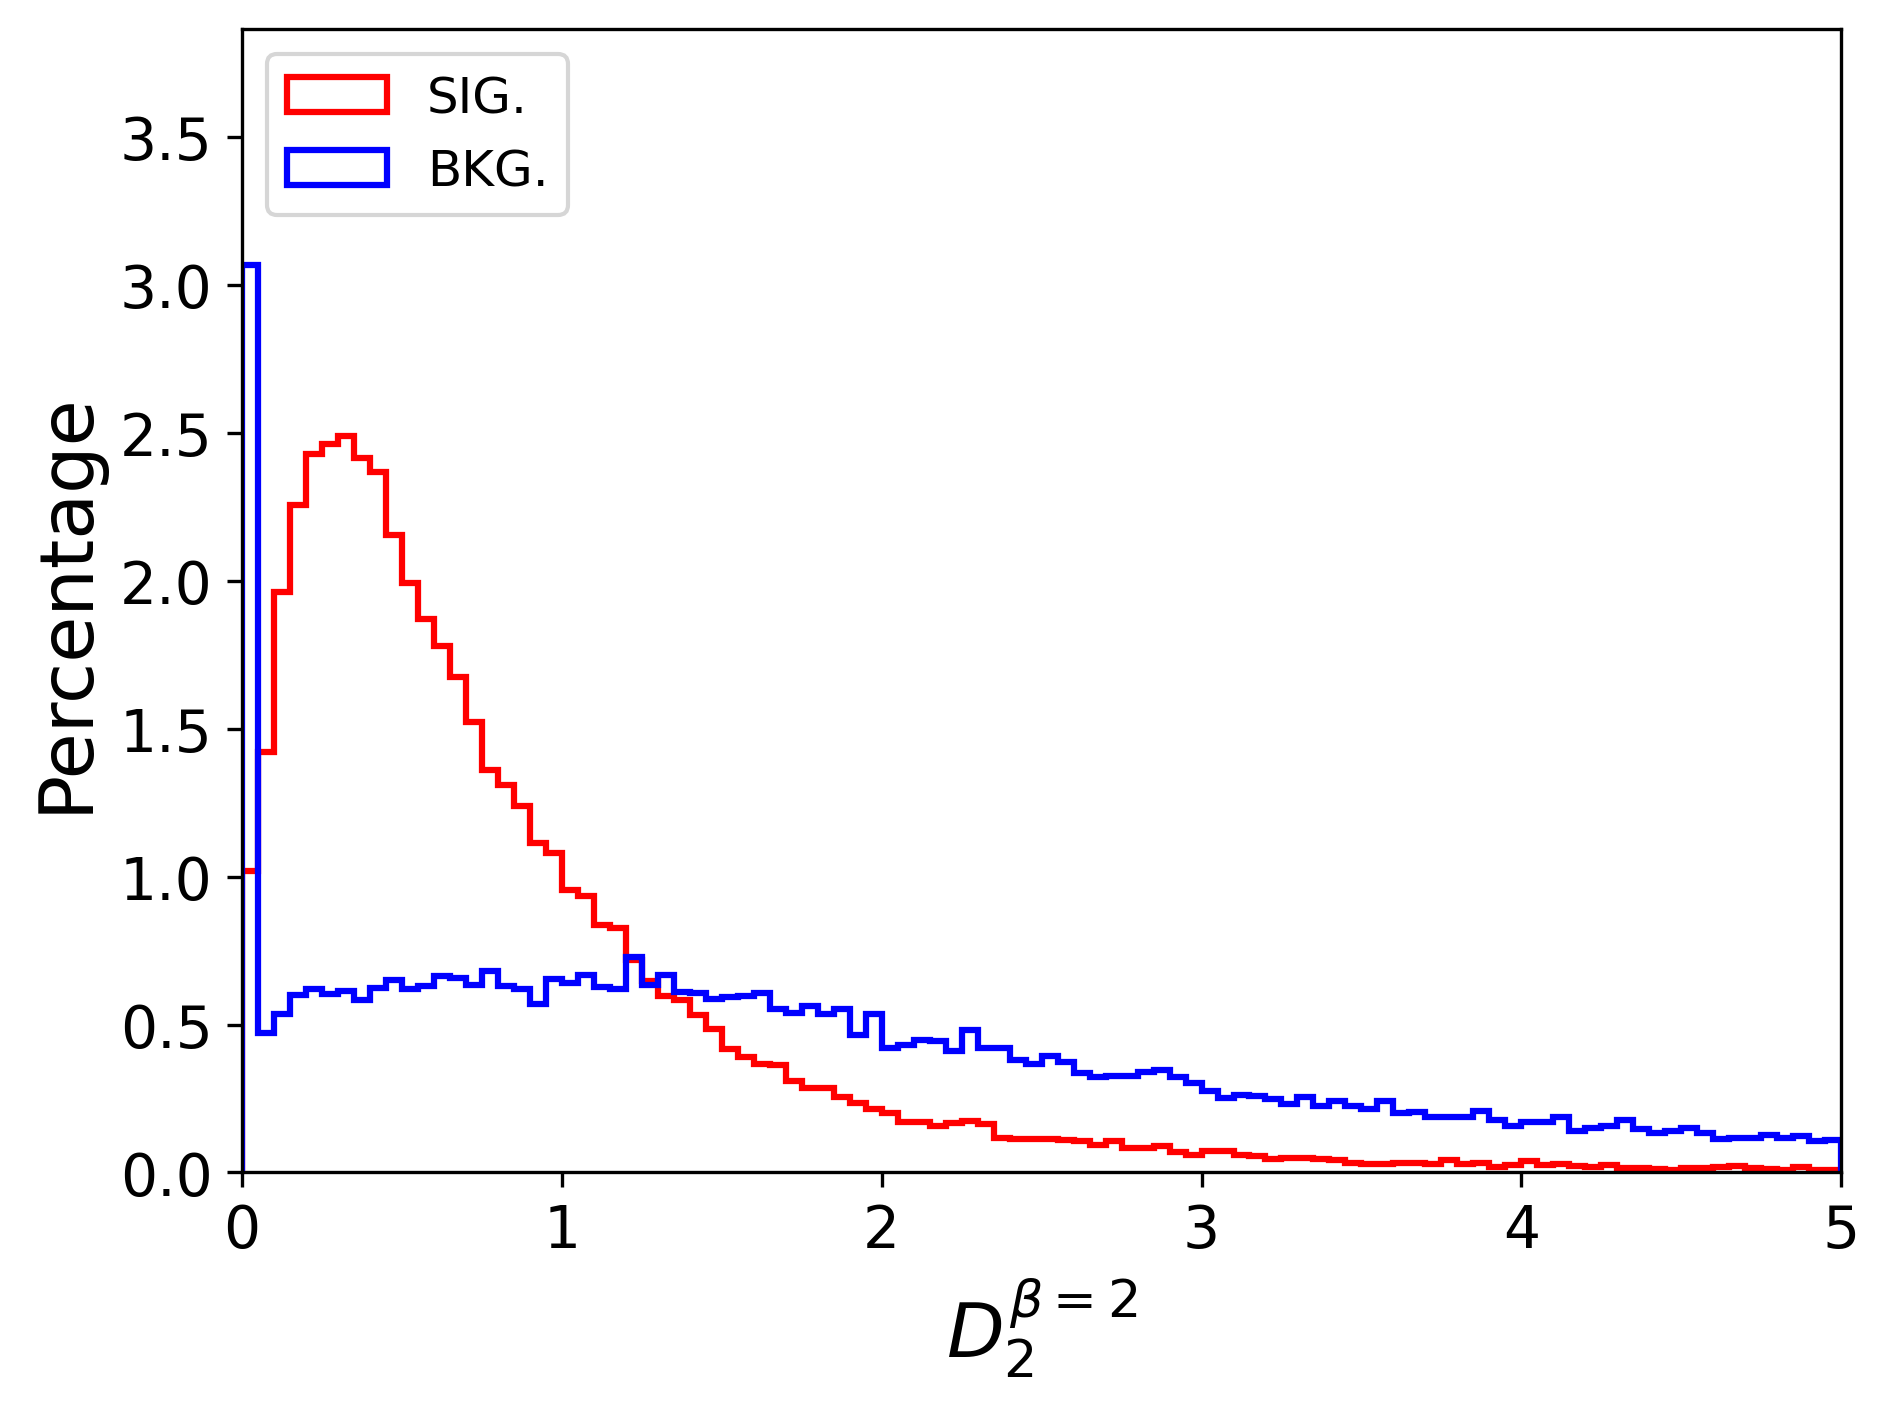

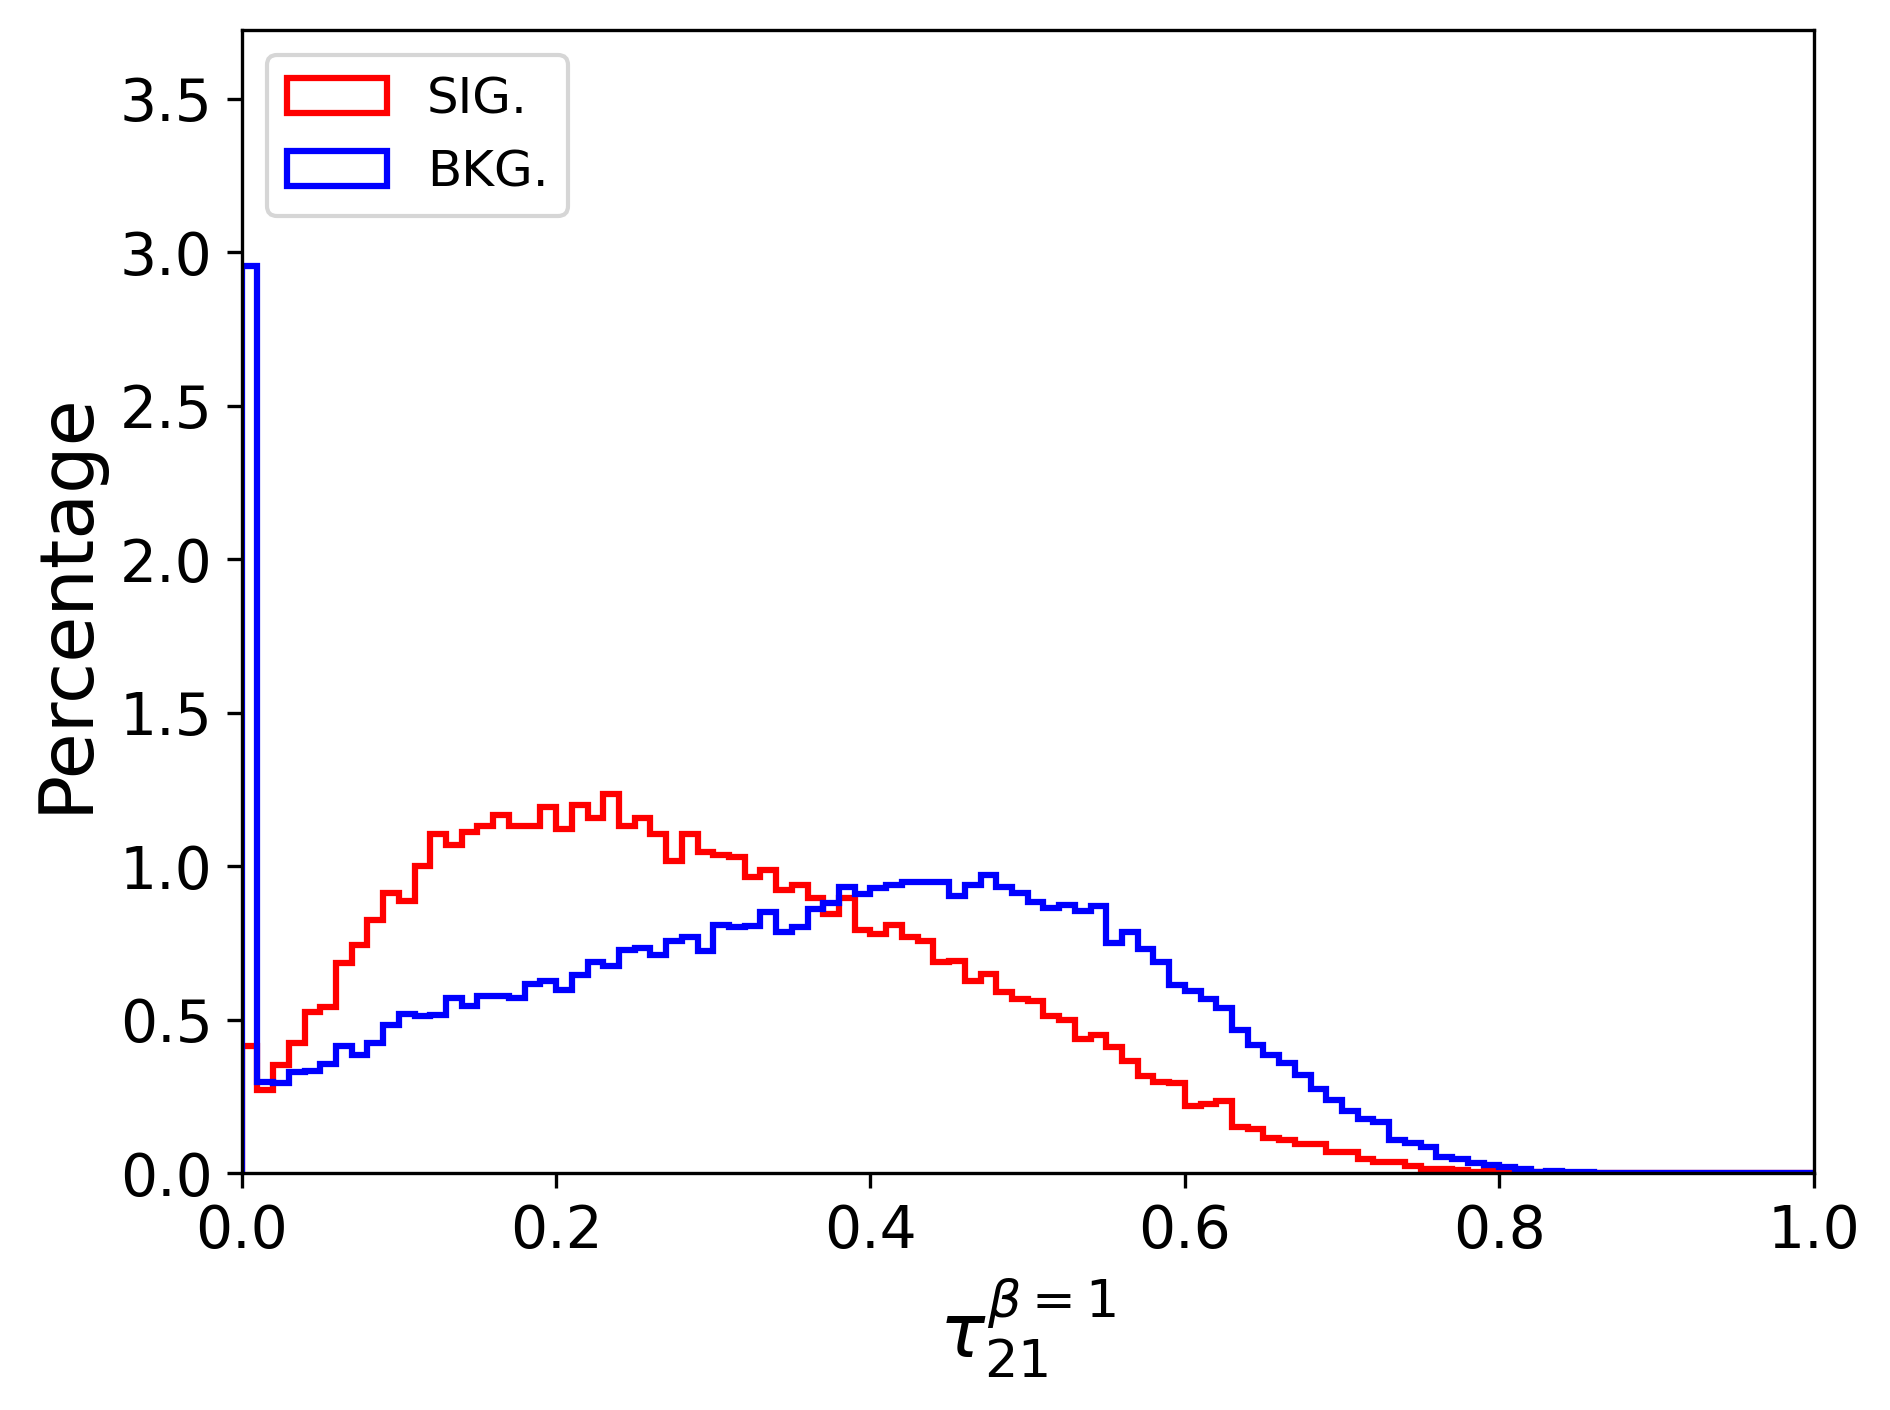

In [6]:
# Figure: distribution
for i, feature in enumerate(features):
    sig = x_train[y_train.squeeze() == 1, i]
    bkg = x_train[y_train.squeeze() == 0, i]
    weights_sig = 100 * np.ones_like(sig) / len(x_train[:, i])
    weights_bkg = 100 * np.ones_like(bkg) / len(x_train[:, i])

    plot_distribution(
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )

    plot_distribution(
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{prefix}distribution:{tex_to_str(feature)}{suffix}.pdf",
    )

    plot_distribution(
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{prefix}distribution:{tex_to_str(feature)}{suffix}.png",
    )